In [1]:
# Canada Japanese SUV Analysis

## 1. Setup
## 2. Data Loading
## 3. Data Cleaning
## 4. Feature Engineering
## 5. Exploratory Data Analysis
## 6. SUV Clustering
## 7. Multicollinearity Check
## 8. Model Comparison with Nested CV
## 9. Final Model and Explainability
## 10. Quantile Regression
## 11. What-if Product Simulation
## 12. Export Results

In [3]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import Lasso, ElasticNet, QuantileRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, silhouette_score
from sklearn.model_selection import GridSearchCV, KFold, LeaveOneOut
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore")

BASE_DIR = Path("/Users/chenjiarui/Desktop/CIVE70122")
DATA_FILE = BASE_DIR / "Canada_JP_SUV_FILLED_FINAL_v2.xlsx"

OUT_DIR = BASE_DIR / "outputs_clean"
OUT_DIR.mkdir(exist_ok=True)

Y_COL = "CA Sales 2026 Jan–Feb"
BASELINE_YEAR = 2026
BASELINE_MONTH = 3

UNDERPERFORMING_BRANDS = {"INFINITI", "MITSUBISHI", "MAZDA", "ACURA"}
RANDOM_STATE = 42

In [4]:
raw = pd.read_excel(DATA_FILE, sheet_name="SUV主表", header=None)
print(raw.shape)
raw.head(8)

(46, 64)


,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
0,Japan Auto SUV — 精简主表 / Consolidated Master Ta...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,识别字段 / Identifiers,NaN,NaN,NaN,NaN,加拿大销量 Canada Sales (T2) · 销量已叠加 / Sales summed,NaN,NaN,NaN,加拿大CO₂ & 油耗 (T3) · 含同级均值 / Incl. class averages,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Match Status,Sources (of 3),Brand,Model,Vehicle Class,CA Sales 2026 Jan–Feb,CA Brand Total,CA Sales Share,Merged From (T2),Engine Size L,...,Seats (max),Boot L (max),Curb Weight kg (max),Front Suspension,Rear Suspension,Steering,AEB,ESP/DSC,Earliest Launch,Merged From (T1)
3,匹配状态,数据源数量（共3个）,品牌,车型,车辆级别,加拿大销量 2026年1-2月,品牌总销量,车型占品牌销量比,合并自（销量来源）,排量（升）,...,座位数（最大）,后备箱容积 L（最大）,整备质量 kg（最大）,前悬架类型,后悬架类型,转向系统,自动紧急制动,车身稳定控制,最早上市时间,合并自（懂车帝来源）
4,✓ T2+T3,2,ACURA,MDX,Mid-size SUV,582,1670,0.348503,MDX,3.5,...,7,2690,2295,Double Wishbone Independent,Multi-Link Independent,Electric Power Steering (EPS),●Standard,●Standard,2000.10,Filled from 2025/2026 Acura MDX official specs...
5,✓ T2+T3,2,ACURA,RDX,Compact SUV,423,1670,0.253293,RDX,3.5,...,5,2260,1815,MacPherson Strut Independent,Multi-Link Independent,Electric Power Steering (EPS),●Standard,●Standard,2006.04,Filled from 2024/2026 Acura RDX official specs
6,✓ All 3,3,HONDA,CR-V,Compact SUV,7886,15583,0.506064,CR-V,2.4,...,7,2166,1923,MacPherson Strut Independent,Multi-Link Independent,Electric Power Steering (EPS),●Standard,●Standard,2002.01,CR-V 2023 240 TURBO CVT 2WD Smart 5-Seat | CR-...
7,✓ All 3,3,HONDA,HR-V,Subcompact SUV,1659,15583,0.106462,HR-V,1.8,...,5,1560,1641,MacPherson Strut Independent,Multi-Link Independent,Electric Power Steering (EPS),●Standard,●Standard,2023.04,HR-V 2023 2.0L e:HEV Dynamic | HR-V 2023 2.0L ...


In [5]:
headers = raw.iloc[2].tolist()   # 第3行英文表头
df = raw.iloc[4:].copy()         # 第5行开始是数据
df.columns = headers
df = df.reset_index(drop=True)

print(df.shape)
df.head()

(42, 64)


,Match Status,Sources (of 3),Brand,Model,Vehicle Class,CA Sales 2026 Jan–Feb,CA Brand Total,CA Sales Share,Merged From (T2),Engine Size L,...,Seats (max),Boot L (max),Curb Weight kg (max),Front Suspension,Rear Suspension,Steering,AEB,ESP/DSC,Earliest Launch,Merged From (T1)
0,✓ T2+T3,2,ACURA,MDX,Mid-size SUV,582,1670,0.348503,MDX,3.5,...,7,2690,2295,Double Wishbone Independent,Multi-Link Independent,Electric Power Steering (EPS),●Standard,●Standard,2000.10,Filled from 2025/2026 Acura MDX official specs...
1,✓ T2+T3,2,ACURA,RDX,Compact SUV,423,1670,0.253293,RDX,3.5,...,5,2260,1815,MacPherson Strut Independent,Multi-Link Independent,Electric Power Steering (EPS),●Standard,●Standard,2006.04,Filled from 2024/2026 Acura RDX official specs
2,✓ All 3,3,HONDA,CR-V,Compact SUV,7886,15583,0.506064,CR-V,2.4,...,7,2166,1923,MacPherson Strut Independent,Multi-Link Independent,Electric Power Steering (EPS),●Standard,●Standard,2002.01,CR-V 2023 240 TURBO CVT 2WD Smart 5-Seat | CR-...
3,✓ All 3,3,HONDA,HR-V,Subcompact SUV,1659,15583,0.106462,HR-V,1.8,...,5,1560,1641,MacPherson Strut Independent,Multi-Link Independent,Electric Power Steering (EPS),●Standard,●Standard,2023.04,HR-V 2023 2.0L e:HEV Dynamic | HR-V 2023 2.0L ...
4,✓ T2+T3,2,HONDA,PASSPORT,Mid-size SUV,508,15583,0.0326,Passport,3.5,...,5,2854,2060,MacPherson Strut Independent,Multi-Link Independent,Electric Power Steering (EPS),●Standard,●Standard,1993.01,Filled from 2025/2026 Honda Passport official ...


In [6]:
df.columns = [str(c).strip() for c in df.columns]

numeric_candidates = [
    "CA Sales 2026 Jan–Feb",
    "WLTC FC L/100km",
    "Max Torque Nm (max)",
    "Max Power PS (max)",
    "Length mm (max)",
    "Width mm (max)",
    "Height mm (max)",
    "Wheelbase mm (max)",
    "Seats (max)",
    "Boot L (max)",
    "Curb Weight kg (max)",
    "Price Proxy CAD",
    "CO₂ g/km",
    "CO₂ g/km (max)",
    "FC Comb L/100km",
]

for c in numeric_candidates:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=[Y_COL]).copy()
df[Y_COL] = pd.to_numeric(df[Y_COL], errors="coerce")
df = df.dropna(subset=[Y_COL]).copy()
df["log_sales"] = np.log1p(df[Y_COL])

print(df.shape)
df[[Y_COL, "log_sales"]].head()

(36, 65)


,CA Sales 2026 Jan–Feb,log_sales
0,582.0,6.368187
1,423.0,6.049733
2,7886.0,8.972971
3,1659.0,7.414573
4,508.0,6.232448


In [7]:
def safe_contains(series, pattern, regex=True):
    return series.astype(str).str.contains(pattern, case=False, regex=regex, na=False)

def months_since_launch(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip()

    if "." in text:
        parts = text.split(".")
        if len(parts) == 2 and parts[0].isdigit() and parts[1].isdigit():
            year = int(parts[0])
            month = int(parts[1])
            if 1 <= month <= 12:
                return (BASELINE_YEAR - year) * 12 + (BASELINE_MONTH - month)

    if text.isdigit() and len(text) == 4:
        year = int(text)
        return (BASELINE_YEAR - year) * 12 + (BASELINE_MONTH - 1)

    return np.nan


df["is_hybrid"] = (
    safe_contains(df.get("Powertrain Type", pd.Series(index=df.index, dtype=object)), r"HEV|PHEV|Hybrid")
    | safe_contains(df.get("Fuel Type [CN]", pd.Series(index=df.index, dtype=object)), r"HEV|PHEV|Hybrid")
).astype(int)

df["is_turbo"] = safe_contains(
    df.get("Induction", pd.Series(index=df.index, dtype=object)),
    r"Turbo"
).astype(int)

df["has_AWD"] = safe_contains(
    df.get("Drive Config", pd.Series(index=df.index, dtype=object)),
    r"AWD|4WD"
).astype(int)

df["has_standard_AEB"] = safe_contains(
    df.get("AEB", pd.Series(index=df.index, dtype=object)),
    r"standard|●standard"
).astype(int)

if "Earliest Launch" in df.columns:
    df["months_since_launch"] = df["Earliest Launch"].apply(months_since_launch)
else:
    df["months_since_launch"] = np.nan

if {"Length mm (max)", "Width mm (max)", "Height mm (max)"}.issubset(df.columns):
    df["volume_m3"] = (
        df["Length mm (max)"] * df["Width mm (max)"] * df["Height mm (max)"] / 1_000_000_000
    )
else:
    df["volume_m3"] = np.nan

if {"Max Power PS (max)", "Curb Weight kg (max)"}.issubset(df.columns):
    df["power_to_weight"] = df["Max Power PS (max)"] / (df["Curb Weight kg (max)"] + 1e-6)
else:
    df["power_to_weight"] = np.nan

if {"Boot L (max)", "volume_m3"}.issubset(df.columns):
    df["boot_to_volume_ratio"] = df["Boot L (max)"] / ((df["volume_m3"] * 1000) + 1e-6)
else:
    df["boot_to_volume_ratio"] = np.nan

df[[
    "is_hybrid", "is_turbo", "has_AWD", "has_standard_AEB",
    "months_since_launch", "volume_m3", "power_to_weight", "boot_to_volume_ratio"
]].head()

,is_hybrid,is_turbo,has_AWD,has_standard_AEB,months_since_launch,volume_m3,power_to_weight,boot_to_volume_ratio
0,0,1,1,1,305.0,16.984010,0.156863,0.158384
1,0,1,1,1,239.0,15.259698,0.152066,0.148103
2,1,1,1,1,290.0,15.892970,0.100364,0.136287
3,1,1,0,1,35.0,13.627682,0.110908,0.114473
4,0,0,1,1,398.0,17.844304,0.140291,0.159939


In [8]:
num_cols_all = df.select_dtypes(include=[np.number]).columns.tolist()
for c in num_cols_all:
    df[c] = df[c].fillna(df[c].median())

model_cols = [
    "Brand", "Model", "Vehicle Class", "Powertrain Type", "Drive Config", "Fuel Type [CN]", "Induction",
    "is_hybrid", "is_turbo", "has_AWD", "has_standard_AEB",
    "months_since_launch", "volume_m3", "power_to_weight", "boot_to_volume_ratio",
    "WLTC FC L/100km", "Max Torque Nm (max)", "Seats (max)", "Curb Weight kg (max)",
    "Length mm (max)", "Wheelbase mm (max)", "Price Proxy CAD", "CO₂ g/km", "CO₂ g/km (max)",
    "FC Comb L/100km", "Max Power PS (max)",
    Y_COL, "log_sales"
]
model_cols = [c for c in model_cols if c in df.columns]

df_model = df[model_cols].copy()
print(df_model.shape)
df_model.head()

(36, 27)


,Brand,Model,Vehicle Class,Powertrain Type,Drive Config,Fuel Type [CN],Induction,is_hybrid,is_turbo,has_AWD,...,Seats (max),Curb Weight kg (max),Length mm (max),Wheelbase mm (max),Price Proxy CAD,CO₂ g/km (max),FC Comb L/100km,Max Power PS (max),CA Sales 2026 Jan–Feb,log_sales
0,ACURA,MDX,Mid-size SUV,Petrol,"FF (Front-Engine, Front-Wheel Drive) / FF/AWD ...",Petrol,Naturally Aspirated / Turbocharged,0,1,1,...,7.0,2295.0,5039.0,2891.0,48974.112138,259.0,11.1,360.0,582.0,6.368187
1,ACURA,RDX,Compact SUV,Petrol,"FF (Front-Engine, Front-Wheel Drive) / FF/AWD ...",Petrol,Turbocharged,0,1,1,...,5.0,1815.0,4750.0,2750.0,48974.112138,250.0,10.7,276.0,423.0,6.049733
2,HONDA,CR-V,Compact SUV,Diesel / Hybrid Electric (HEV) / Petrol / Plug...,"FF (Front-Engine, Front-Wheel Drive) / FF/AWD ...",Diesel / Hybrid Electric (HEV) / Petrol / Plug...,Naturally Aspirated / Turbocharged,1,1,1,...,7.0,1923.0,4703.0,2701.0,31229.348315,216.0,9.4,193.0,7886.0,8.972971
3,HONDA,HR-V,Subcompact SUV,Hybrid Electric (HEV) / Petrol,"FF (Front-Engine, Front-Wheel Drive)",Hybrid Electric (HEV) / Petrol,Naturally Aspirated / Turbocharged,1,1,0,...,5.0,1641.0,4569.0,2655.0,31229.348315,200.0,8.5,182.0,1659.0,7.414573
4,HONDA,PASSPORT,Mid-size SUV,Petrol,"FF/AWD (Front-Engine, All-Wheel Drive)",Petrol,Naturally Aspirated,0,0,1,...,5.0,2060.0,4864.0,2885.0,31229.348315,265.0,11.3,289.0,508.0,6.232448


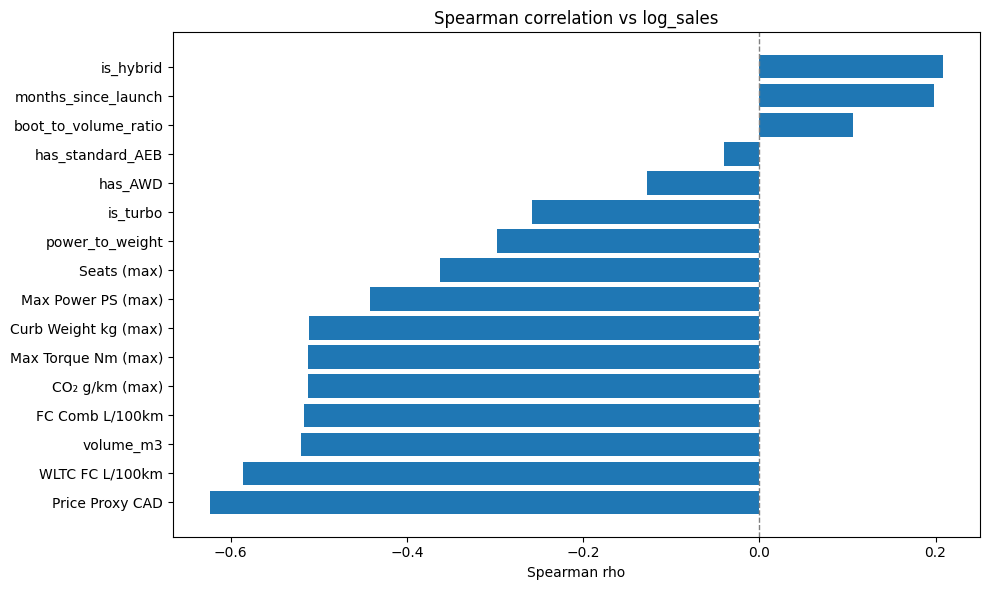

Price Proxy CAD        -0.623865
WLTC FC L/100km        -0.586365
volume_m3              -0.520626
FC Comb L/100km        -0.516982
CO₂ g/km (max)         -0.512784
Max Torque Nm (max)    -0.511922
Curb Weight kg (max)   -0.511781
Max Power PS (max)     -0.441682
Seats (max)            -0.362079
power_to_weight        -0.297960
is_turbo               -0.257629
has_AWD                -0.127627
has_standard_AEB       -0.040678
boot_to_volume_ratio    0.106805
months_since_launch     0.198365
is_hybrid               0.208815
Name: log_sales, dtype: float64

In [9]:
numeric_engineered = [
    c for c in [
        "is_hybrid", "is_turbo", "has_AWD", "has_standard_AEB",
        "months_since_launch", "volume_m3", "power_to_weight",
        "boot_to_volume_ratio", "WLTC FC L/100km", "Max Torque Nm (max)",
        "Seats (max)", "Curb Weight kg (max)", "Price Proxy CAD",
        "CO₂ g/km", "CO₂ g/km (max)", "FC Comb L/100km", "Max Power PS (max)"
    ] if c in df_model.columns
]

spearman_corr = (
    df_model[["log_sales"] + numeric_engineered]
    .corr(method="spearman")["log_sales"]
    .drop("log_sales")
    .sort_values()
)

plt.figure(figsize=(10, 6))
plt.barh(spearman_corr.index, spearman_corr.values)
plt.axvline(0, color="gray", linestyle="--", linewidth=1)
plt.title("Spearman correlation vs log_sales")
plt.xlabel("Spearman rho")
plt.tight_layout()
plt.show()

spearman_corr

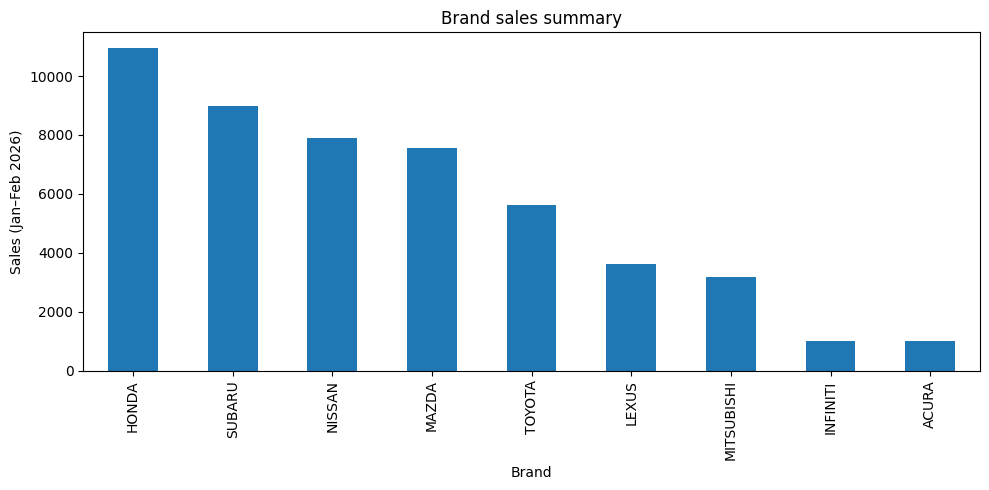

Brand
HONDA         10939.0
SUBARU         8982.0
NISSAN         7891.0
MAZDA          7568.0
TOYOTA         5628.0
LEXUS          3603.0
MITSUBISHI     3195.0
INFINITI       1009.0
ACURA          1005.0
Name: CA Sales 2026 Jan–Feb, dtype: float64

In [10]:
brand_sales = df_model.groupby("Brand")[Y_COL].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
brand_sales.plot(kind="bar")
plt.title("Brand sales summary")
plt.ylabel("Sales (Jan–Feb 2026)")
plt.tight_layout()
plt.show()

brand_sales

In [11]:
cluster_features = [
    c for c in [
        "Price Proxy CAD",
        "WLTC FC L/100km",
        "FC Comb L/100km",
        "CO₂ g/km", "CO₂ g/km (max)",
        "volume_m3",
        "boot_to_volume_ratio",
        "power_to_weight",
        "Max Torque Nm (max)",
        "months_since_launch",
        "is_hybrid",
        "has_AWD",
        "Seats (max)"
    ] if c in df_model.columns
]

df_cluster = df_model[["Brand", "Model"] + cluster_features].copy()
X_cluster = df_cluster[cluster_features].copy()

cluster_scaler = StandardScaler()
X_cluster_scaled = cluster_scaler.fit_transform(X_cluster)

print("Cluster feature count:", len(cluster_features))
print(cluster_features)

Cluster feature count: 12
['Price Proxy CAD', 'WLTC FC L/100km', 'FC Comb L/100km', 'CO₂ g/km (max)', 'volume_m3', 'boot_to_volume_ratio', 'power_to_weight', 'Max Torque Nm (max)', 'months_since_launch', 'is_hybrid', 'has_AWD', 'Seats (max)']


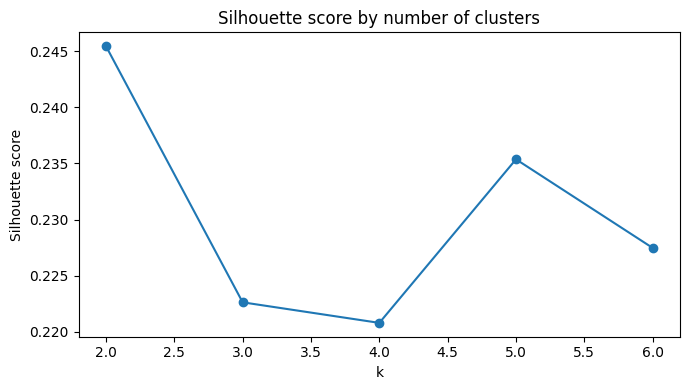

,k,silhouette_score
0,2,0.245430
1,3,0.222629
2,4,0.220798
3,5,0.235359
4,6,0.227471


In [12]:
sil_scores = []
k_values = range(2, 7)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = km.fit_predict(X_cluster_scaled)
    score = silhouette_score(X_cluster_scaled, labels)
    sil_scores.append(score)

plt.figure(figsize=(7, 4))
plt.plot(list(k_values), sil_scores, marker="o")
plt.title("Silhouette score by number of clusters")
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.tight_layout()
plt.show()

pd.DataFrame({"k": list(k_values), "silhouette_score": sil_scores})

In [13]:
best_k = list(k_values)[int(np.argmax(sil_scores))]
print("Best k from silhouette:", best_k)

kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=20)
df_cluster["cluster"] = kmeans.fit_predict(X_cluster_scaled)

df_cluster[["Brand", "Model", "cluster"]].head(10)

Best k from silhouette: 2


,Brand,Model,cluster
0,ACURA,MDX,1
1,ACURA,RDX,0
2,HONDA,CR-V,0
3,HONDA,HR-V,0
4,HONDA,PASSPORT,1
5,HONDA,PILOT,1
6,INFINITI,QX50,0
7,INFINITI,QX55,0
8,INFINITI,QX60,1
9,INFINITI,QX80,1


In [14]:
cluster_profile = df_cluster.groupby("cluster")[cluster_features].mean().round(3)
cluster_counts = df_cluster["cluster"].value_counts().sort_index()

print("Cluster counts:")
display(cluster_counts)

print("Cluster profile:")
display(cluster_profile)

Cluster counts:


cluster
0    22
1    14
Name: count, dtype: int64

Cluster profile:


,Price Proxy CAD,WLTC FC L/100km,FC Comb L/100km,CO₂ g/km (max),volume_m3,boot_to_volume_ratio,power_to_weight,Max Torque Nm (max),months_since_launch,is_hybrid,has_AWD,Seats (max)
cluster,,,,,,,,,,,,
0,35592.340,7.847,9.932,231.500,14.558,0.122,0.121,312.945,152.409,0.455,0.818,5.182
1,44967.324,10.654,13.214,307.714,18.625,0.132,0.137,496.214,252.714,0.357,1.000,7.214


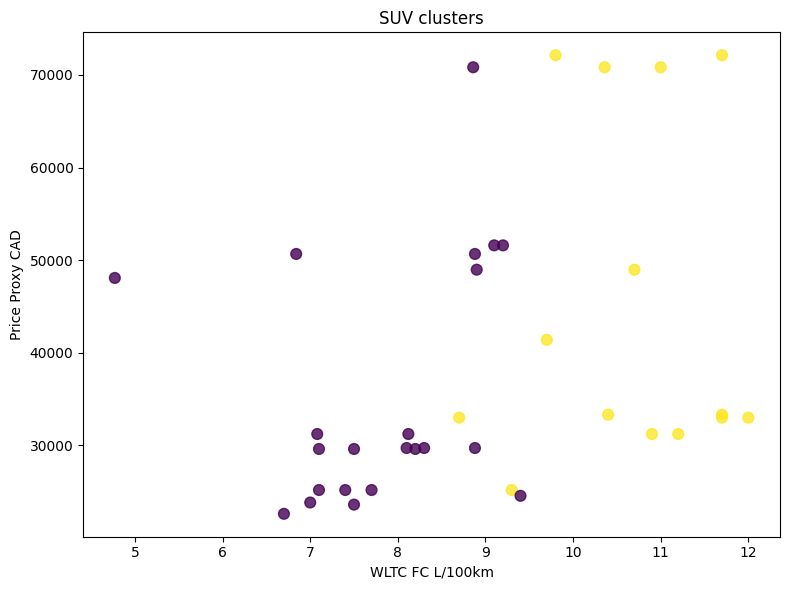

In [15]:
plot_x = "WLTC FC L/100km" if "WLTC FC L/100km" in df_cluster.columns else cluster_features[0]
plot_y = "Price Proxy CAD" if "Price Proxy CAD" in df_cluster.columns else cluster_features[1]

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    df_cluster[plot_x],
    df_cluster[plot_y],
    c=df_cluster["cluster"],
    s=60,
    alpha=0.8
)
plt.xlabel(plot_x)
plt.ylabel(plot_y)
plt.title("SUV clusters")
plt.tight_layout()
plt.show()

In [16]:
df_model = df_model.merge(
    df_cluster[["Brand", "Model", "cluster"]],
    on=["Brand", "Model"],
    how="left"
)

df_model[["Brand", "Model", "cluster"]].head()

,Brand,Model,cluster
0,ACURA,MDX,1
1,ACURA,RDX,0
2,HONDA,CR-V,0
3,HONDA,HR-V,0
4,HONDA,PASSPORT,1


In [17]:
vif_features = df_model[numeric_engineered].copy()
X_vif = sm.add_constant(vif_features)

vif_df = pd.DataFrame({
    "Feature": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values("VIF", ascending=False)

vif_df

,Feature,VIF
0,const,2281.576234
15,FC Comb L/100km,915.053261
14,CO₂ g/km (max),913.600103
16,Max Power PS (max),239.862850
12,Curb Weight kg (max),128.949893
7,power_to_weight,47.534543
10,Max Torque Nm (max),28.766350
6,volume_m3,27.388943
9,WLTC FC L/100km,9.334624
5,months_since_launch,4.454408


In [18]:
numeric_cols = [
    c for c in [
        "is_hybrid", "is_turbo", "has_AWD", "has_standard_AEB",
        "months_since_launch", "volume_m3", "power_to_weight",
        "boot_to_volume_ratio", "WLTC FC L/100km", "Max Torque Nm (max)",
        "Seats (max)", "Curb Weight kg (max)", "Length mm (max)",
        "Wheelbase mm (max)", "Price Proxy CAD", "CO₂ g/km", "CO₂ g/km (max)",
        "FC Comb L/100km", "Max Power PS (max)", "cluster"
    ] if c in df_model.columns
]

categorical_cols = [
    c for c in ["Brand", "Vehicle Class", "Powertrain Type", "Drive Config", "Fuel Type [CN]", "Induction"]
    if c in df_model.columns
]

X = df_model[numeric_cols + categorical_cols].copy()
y = df_model["log_sales"].copy()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ],
    remainder="drop",
)

print(X.shape, y.shape)

(36, 25) (36,)


In [19]:
def evaluate_predictions(y_true_log, y_pred_log):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    return {
        "MAE_units": mean_absolute_error(y_true, y_pred),
        "RMSE_units": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2_log": r2_score(y_true_log, y_pred_log),
    }

models = {
    "lasso": (
        Pipeline([
            ("prep", preprocessor),
            ("model", Lasso(max_iter=50000, tol=1e-3, random_state=42))
        ]),
        {"model__alpha": np.logspace(-3, 1, 20)}
    ),
    "elasticnet": (
        Pipeline([
            ("prep", preprocessor),
            ("model", ElasticNet(max_iter=50000, tol=1e-3, random_state=42))
        ]),
        {
            "model__alpha": np.logspace(-3, 1, 10),
            "model__l1_ratio": [0.2, 0.5, 0.8, 1.0]
        }
    ),
    "rf": (
        Pipeline([
            ("prep", preprocessor),
            ("model", RandomForestRegressor(random_state=42))
        ]),
        {
            "model__n_estimators": [100, 300],
            "model__max_depth": [2, 3, 4, None],
            "model__min_samples_leaf": [1, 2, 4]
        }
    )
}

outer_cv = LeaveOneOut()
inner_cv = KFold(n_splits=5, shuffle=True, random_state=42)

results = []

for model_name, (pipe, grid) in models.items():
    outer_true = []
    outer_pred = []

    for train_idx, test_idx in outer_cv.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        gs = GridSearchCV(
            estimator=pipe,
            param_grid=grid,
            cv=inner_cv,
            scoring="neg_mean_absolute_error",
            n_jobs=-1
        )
        gs.fit(X_train, y_train)
        pred = gs.best_estimator_.predict(X_test)[0]

        outer_true.append(float(y_test.iloc[0]))
        outer_pred.append(float(pred))

    metrics = evaluate_predictions(np.array(outer_true), np.array(outer_pred))
    metrics["model"] = model_name
    results.append(metrics)

results_df = pd.DataFrame(results).sort_values("RMSE_units")
results_df

,MAE_units,RMSE_units,R2_log,model
2,796.740515,1464.492560,0.432633,rf
0,871.396871,1515.700203,0.439556,lasso
1,889.019740,1554.780320,0.367065,elasticnet


In [20]:
best_model_name = results_df.iloc[0]["model"]
print("Best model:", best_model_name)

best_pipe, best_grid = models[best_model_name]

final_search = GridSearchCV(
    estimator=best_pipe,
    param_grid=best_grid,
    cv=inner_cv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)
final_search.fit(X, y)

final_model = final_search.best_estimator_
final_search.best_params_

Best model: rf


{'model__max_depth': None,
 'model__min_samples_leaf': 1,
 'model__n_estimators': 300}

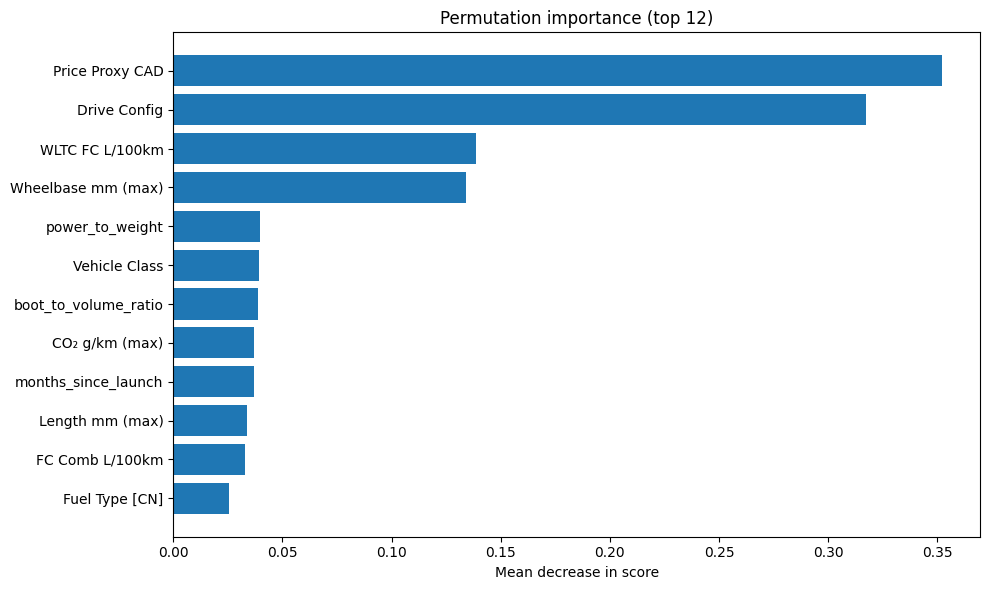

,feature,importance_mean,importance_std
14,Price Proxy CAD,0.351908,0.075126
22,Drive Config,0.317371,0.064418
8,WLTC FC L/100km,0.138818,0.038704
13,Wheelbase mm (max),0.134320,0.037802
6,power_to_weight,0.039627,0.008047
20,Vehicle Class,0.039501,0.009768
7,boot_to_volume_ratio,0.039044,0.011082
15,CO₂ g/km (max),0.037035,0.008614
4,months_since_launch,0.036806,0.007866
12,Length mm (max),0.033569,0.010631


In [21]:
perm = permutation_importance(
    final_model,
    X,
    y,
    n_repeats=50,
    random_state=42,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "feature": X.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)

plt.figure(figsize=(10, 6))
top_perm = perm_df.head(12).iloc[::-1]
plt.barh(top_perm["feature"], top_perm["importance_mean"])
plt.title("Permutation importance (top 12)")
plt.xlabel("Mean decrease in score")
plt.tight_layout()
plt.show()

perm_df.head(15)

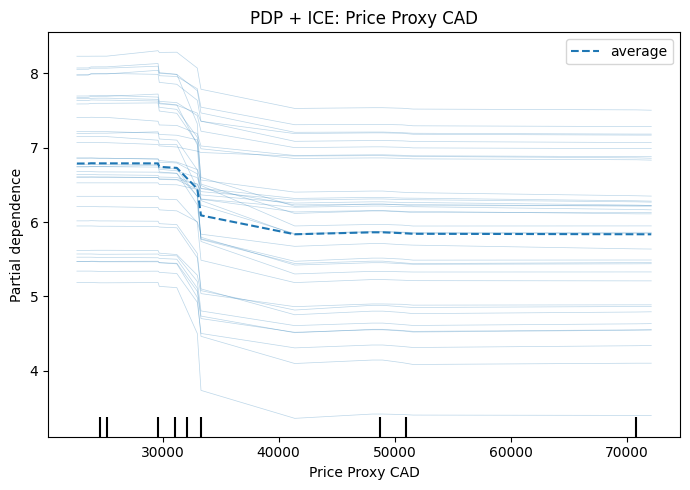

Skipping Drive Config: The column #0 contains mixed data types. Finding unique categories fail due to sorting. It usually means that the column contains `np.nan` values together with `str` categories. Such use case is not yet supported in scikit-learn.


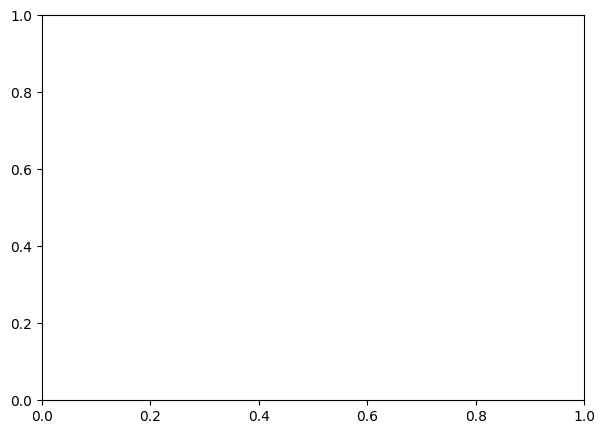

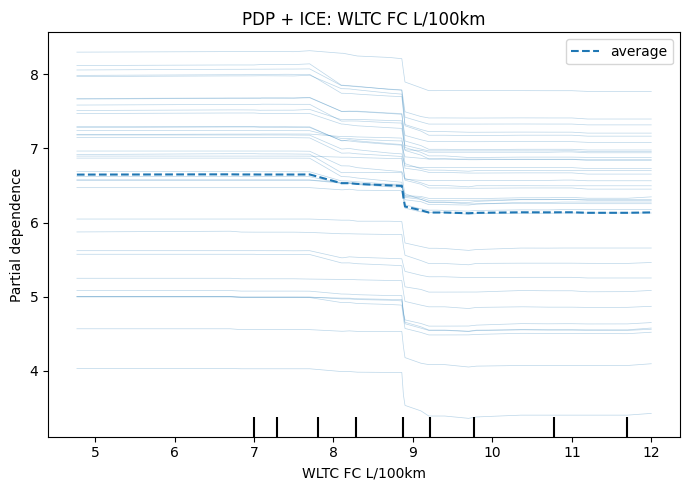

In [22]:
top_pdp_features = perm_df["feature"].head(3).tolist()

for feat in top_pdp_features:
    fig, ax = plt.subplots(figsize=(7, 5))
    try:
        PartialDependenceDisplay.from_estimator(
            final_model,
            X,
            [feat],
            kind="both",
            ax=ax
        )
        ax.set_title(f"PDP + ICE: {feat}")
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Skipping {feat}: {e}")

In [23]:
qr_features = [c for c in numeric_cols if c in X.columns]
X_qr = df_model[qr_features].copy()

qr_scaler = StandardScaler()
X_qr_scaled = pd.DataFrame(
    qr_scaler.fit_transform(X_qr),
    columns=qr_features,
    index=X_qr.index
)

quantiles = [0.1, 0.5, 0.9]
qr_models = {}

for q in quantiles:
    qr = QuantileRegressor(quantile=q, alpha=0.1, solver="highs")
    qr.fit(X_qr_scaled, y)
    qr_models[q] = qr

print("Quantile models fitted.")

Quantile models fitted.


In [24]:
def predict_sales_with_final_model(row_df):
    pred_log = final_model.predict(row_df)[0]
    return float(np.expm1(pred_log))

def predict_sales_interval_with_qr(row_df):
    row_qr = row_df[qr_features].copy()
    row_qr_scaled = pd.DataFrame(
        qr_scaler.transform(row_qr),
        columns=qr_features,
        index=row_qr.index,
    )
    p10 = float(np.expm1(qr_models[0.1].predict(row_qr_scaled)[0]))
    p50 = float(np.expm1(qr_models[0.5].predict(row_qr_scaled)[0]))
    p90 = float(np.expm1(qr_models[0.9].predict(row_qr_scaled)[0]))
    return p10, p50, p90

candidates = df_model[df_model["Brand"].isin(UNDERPERFORMING_BRANDS)].copy()
if len(candidates) == 0:
    candidates = df_model.copy()

worst_row = candidates.nsmallest(1, Y_COL).iloc[0]
worst_idx = worst_row.name
vehicle_name = f"{worst_row['Brand']} {worst_row['Model']}"

base_row = X.loc[[worst_idx]].copy()
base_sales = predict_sales_with_final_model(base_row)
base_p10, base_p50, base_p90 = predict_sales_interval_with_qr(base_row)

print("Selected vehicle:", vehicle_name)
print("Baseline predicted sales:", round(base_sales, 1))
print("Baseline interval:", round(base_p10,1), round(base_p50,1), round(base_p90,1))

Selected vehicle: INFINITI QX55
Baseline predicted sales: 58.4
Baseline interval: 68.0 632.4 3583.0


In [25]:
scenarios = []

# Scenario A: add hybrid label only
hypo_A = base_row.copy()
if "is_hybrid" in hypo_A.columns:
    hypo_A["is_hybrid"] = 1
sales_A = predict_sales_with_final_model(hypo_A)
A_p10, A_p50, A_p90 = predict_sales_interval_with_qr(hypo_A)

scenarios.append({
    "scenario": "A_label_hybrid_only",
    "pred_sales": sales_A,
    "p10": A_p10,
    "p50": A_p50,
    "p90": A_p90,
    "uplift_vs_base": sales_A - base_sales,
})

# Scenario B: improve fuel economy + soften torque
hypo_B = base_row.copy()
if "WLTC FC L/100km" in hypo_B.columns:
    hypo_B["WLTC FC L/100km"] = hypo_B["WLTC FC L/100km"] * 0.85
if "Max Torque Nm (max)" in hypo_B.columns:
    hypo_B["Max Torque Nm (max)"] = np.minimum(hypo_B["Max Torque Nm (max)"], 280.0)
sales_B = predict_sales_with_final_model(hypo_B)
B_p10, B_p50, B_p90 = predict_sales_interval_with_qr(hypo_B)

scenarios.append({
    "scenario": "B_improve_fc_reduce_torque",
    "pred_sales": sales_B,
    "p10": B_p10,
    "p50": B_p50,
    "p90": B_p90,
    "uplift_vs_base": sales_B - base_sales,
})

# Scenario C: true hybrid + stronger efficiency improvement
hypo_C = base_row.copy()
if "is_hybrid" in hypo_C.columns:
    hypo_C["is_hybrid"] = 1
if "WLTC FC L/100km" in hypo_C.columns:
    hypo_C["WLTC FC L/100km"] = hypo_C["WLTC FC L/100km"] * 0.65
if "Max Torque Nm (max)" in hypo_C.columns:
    hypo_C["Max Torque Nm (max)"] = np.minimum(hypo_C["Max Torque Nm (max)"], 250.0)
sales_C = predict_sales_with_final_model(hypo_C)
C_p10, C_p50, C_p90 = predict_sales_interval_with_qr(hypo_C)

scenarios.append({
    "scenario": "C_true_hybrid_efficiency_pivot",
    "pred_sales": sales_C,
    "p10": C_p10,
    "p50": C_p50,
    "p90": C_p90,
    "uplift_vs_base": sales_C - base_sales,
})

scenario_df = pd.DataFrame(scenarios)
scenario_df.insert(0, "vehicle", vehicle_name)
scenario_df.insert(1, "baseline_pred_sales", base_sales)

scenario_df

,vehicle,baseline_pred_sales,scenario,pred_sales,p10,p50,p90,uplift_vs_base
0,INFINITI QX55,58.352215,A_label_hybrid_only,60.023101,68.0,632.437193,3583.0,1.670886
1,INFINITI QX55,58.352215,B_improve_fc_reduce_torque,102.118469,68.0,632.437193,3583.0,43.766254
2,INFINITI QX55,58.352215,C_true_hybrid_efficiency_pivot,105.386905,68.0,632.437193,3583.0,47.034690


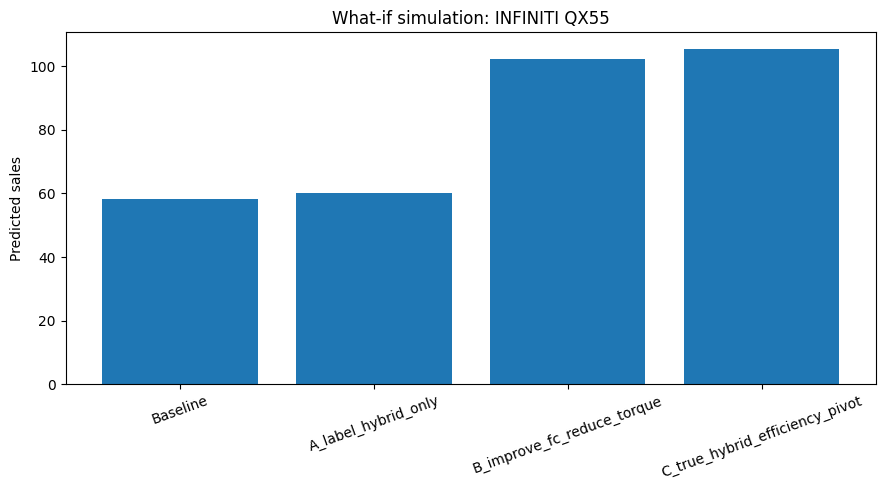

In [26]:
plot_df = pd.concat([
    pd.DataFrame([{"scenario": "Baseline", "pred_sales": base_sales}]),
    scenario_df[["scenario", "pred_sales"]]
], ignore_index=True)

plt.figure(figsize=(9, 5))
plt.bar(plot_df["scenario"], plot_df["pred_sales"])
plt.title(f"What-if simulation: {vehicle_name}")
plt.ylabel("Predicted sales")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [27]:
df_model.to_csv(OUT_DIR / "clean_engineered_data.csv", index=False, encoding="utf-8-sig")
results_df.to_csv(OUT_DIR / "nested_cv_model_comparison.csv", index=False, encoding="utf-8-sig")
perm_df.to_csv(OUT_DIR / "permutation_importance.csv", index=False, encoding="utf-8-sig")
scenario_df.to_csv(OUT_DIR / "what_if_scenarios.csv", index=False, encoding="utf-8-sig")
cluster_profile.to_csv(OUT_DIR / "cluster_profile.csv", encoding="utf-8-sig")
df_cluster.to_csv(OUT_DIR / "cluster_assignments.csv", index=False, encoding="utf-8-sig")

print("Saved all outputs to:", OUT_DIR)

Saved all outputs to: /Users/chenjiarui/Desktop/CIVE70122/outputs_clean
